In [ ]:
import pandas as pd
test_df = pd.read_csv('test.csv')
train_df = pd.read_csv('train.csv')
valid_df = pd.read_csv('valid.csv')

print(test_df.shape)
print(train_df.shape)
print(valid_df.shape)

(4232, 2)
(10000, 2)
(4232, 2)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [ ]:
STUDENT_NUMBER = 2023172283

In [ ]:
# PART 1: MODEL TRAINING
print("PART 1: MODEL TRAINING & EVALUATION")

# Vectorization
print("Vectorizing text (TF-IDF)")
vectorizer = TfidfVectorizer(stop_words=None, max_features=5000)
X_train = vectorizer.fit_transform(train_df['text'])
y_train = train_df['label']
X_test = vectorizer.transform(test_df['text'])
y_test = test_df['label']

# Initialize Models
models = {
    "Logistic Regression": LogisticRegression(random_state=STUDENT_NUMBER, max_iter=1000),
    "Linear SVM": LinearSVC(random_state=STUDENT_NUMBER, dual='auto'),
    "Random Forest": RandomForestClassifier(random_state=STUDENT_NUMBER)
}

results = {}
predictions = {}

# Train, Predict, and Generate Full Reports
for name, model in models.items():
    print(f"\nTraining {name}")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    # Metrics
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    predictions[name] = y_pred

    print(f"Accuracy: {acc:.4f}")
    print("Classification Report:")
    print(classification_report(y_test, y_pred, target_names=['Non-Hate (0)', 'Hate (1)']))

PART 1: MODEL TRAINING & EVALUATION
Vectorizing text (TF-IDF)

Training Logistic Regression
Accuracy: 0.7457
Classification Report:
              precision    recall  f1-score   support

Non-Hate (0)       0.74      0.79      0.77      2225
    Hate (1)       0.75      0.70      0.72      2007

    accuracy                           0.75      4232
   macro avg       0.75      0.74      0.74      4232
weighted avg       0.75      0.75      0.75      4232


Training Linear SVM
Accuracy: 0.7467
Classification Report:
              precision    recall  f1-score   support

Non-Hate (0)       0.74      0.79      0.77      2225
    Hate (1)       0.75      0.70      0.72      2007

    accuracy                           0.75      4232
   macro avg       0.75      0.74      0.74      4232
weighted avg       0.75      0.75      0.75      4232


Training Random Forest
Accuracy: 0.7219
Classification Report:
              precision    recall  f1-score   support

Non-Hate (0)       0.72      0.76 

PART 2: EXPLORATORY DATA ANALYSIS (EDA)


/tmp/ipython-input-3833699512.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='label', data=train_df, palette='viridis')


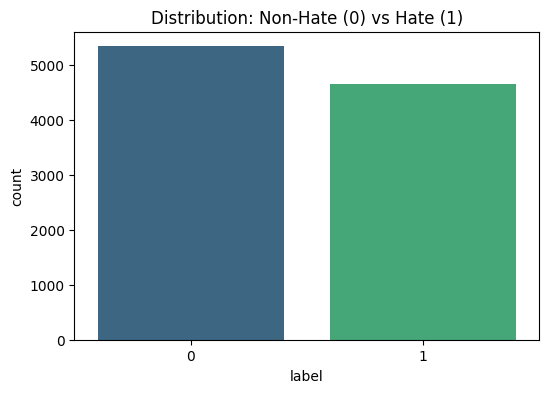

Generating Feature Importance using: Linear SVM


/tmp/ipython-input-3833699512.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coef', y='word', data=top_hate, ax=axes[0], palette='Reds_r')
/tmp/ipython-input-3833699512.py:31: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='coef', y='word', data=top_non_hate, ax=axes[1], palette='Blues_r')


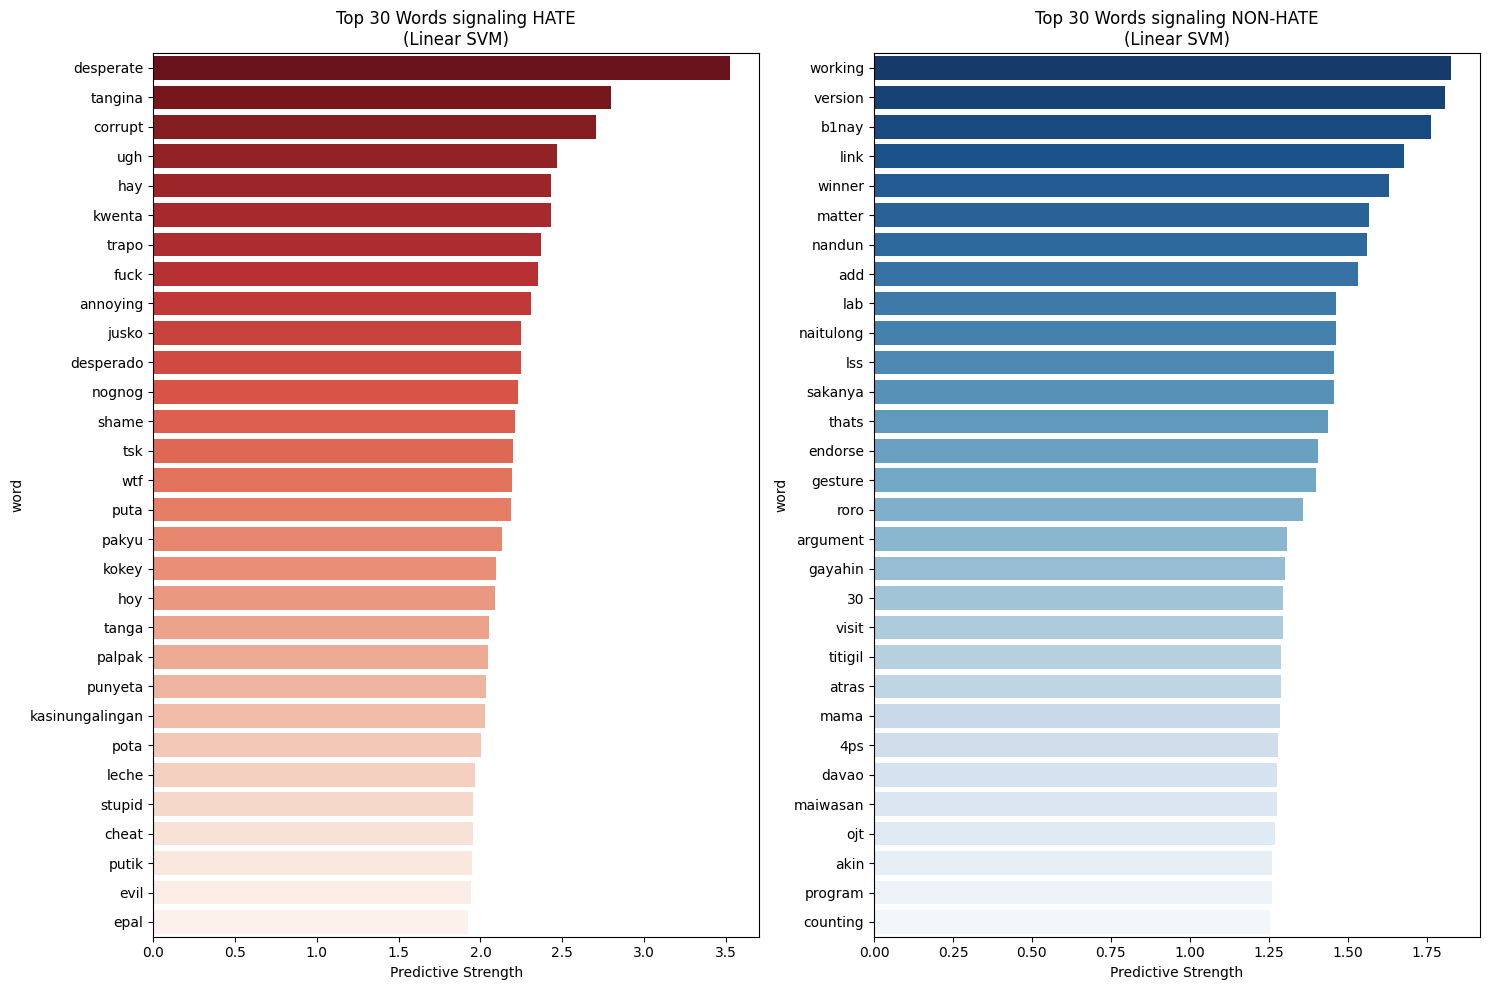

In [ ]:
# PART 2: EXPLORATORY DATA ANALYSIS (EDA)
print("PART 2: EXPLORATORY DATA ANALYSIS (EDA)")

# Class Distribution
plt.figure(figsize=(6, 4))
sns.countplot(x='label', data=train_df, palette='viridis')
plt.title('Distribution: Non-Hate (0) vs Hate (1)')
plt.show()

# Feature Importance
print("Generating Feature Importance using: Linear SVM")
model_for_viz = models["Linear SVM"]

coefs = model_for_viz.coef_[0]
feature_names = vectorizer.get_feature_names_out()
feature_df = pd.DataFrame({'word': feature_names, 'coef': coefs})

# Top 30 Words
top_k = 30
top_hate = feature_df.sort_values(by='coef', ascending=False).head(top_k)
top_non_hate = feature_df.sort_values(by='coef', ascending=True).head(top_k)
top_non_hate['coef'] = top_non_hate['coef'].abs()

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 10))

sns.barplot(x='coef', y='word', data=top_hate, ax=axes[0], palette='Reds_r')
axes[0].set_title(f'Top {top_k} Words signaling HATE\n(Linear SVM)')
axes[0].set_xlabel('Predictive Strength')

sns.barplot(x='coef', y='word', data=top_non_hate, ax=axes[1], palette='Blues_r')
axes[1].set_title(f'Top {top_k} Words signaling NON-HATE\n(Linear SVM)')
axes[1].set_xlabel('Predictive Strength')

plt.tight_layout()
plt.show()

PART 3: RANKING & ANALYSIS
HIGHEST Performing Model: Linear SVM
LOWEST Performing Model: Random Forest


/tmp/ipython-input-3418797642.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=model_names, y=scores, palette='viridis')


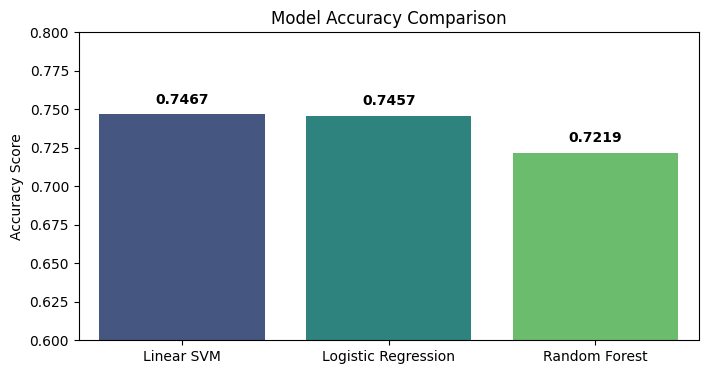


Generating Confusion Matrix for the BEST Model (Linear SVM)...


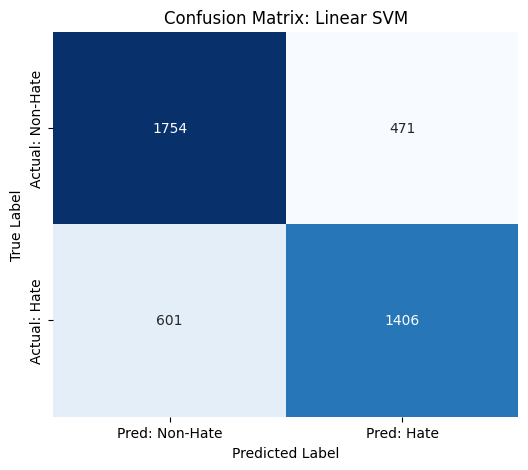

In [ ]:
# PART 3: RANKING & ANALYSIS
print("PART 3: RANKING & ANALYSIS")

# Sort results
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)
best_model_name = sorted_results[0][0]
worst_model_name = sorted_results[-1][0]

print(f"HIGHEST Performing Model: {best_model_name}")
print(f"LOWEST Performing Model: {worst_model_name}")

# ACCURACY BAR CHART
model_names = [x[0] for x in sorted_results]
scores = [x[1] for x in sorted_results]

plt.figure(figsize=(8, 4))
ax = sns.barplot(x=model_names, y=scores, palette='viridis')
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy Score')
plt.ylim(0.6, 0.8) # Zoom in to show differences
for i, v in enumerate(scores):
    ax.text(i, v + 0.005, f"{v:.4f}", ha='center', va='bottom', fontweight='bold')
plt.show()

# CONFUSION MATRIX
print(f"\nGenerating Confusion Matrix for the BEST Model ({best_model_name})...")
cm = confusion_matrix(y_test, predictions[best_model_name])

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Pred: Non-Hate', 'Pred: Hate'],
            yticklabels=['Actual: Non-Hate', 'Actual: Hate'])
plt.title(f'Confusion Matrix: {best_model_name}')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.show()

In [ ]:
# PART 4: HARD TO CLASSIFY SAMPLES
print("PART 4: HARD TO CLASSIFY SAMPLES")

pred_best = predictions[best_model_name]
pred_worst = predictions[worst_model_name]

# Identify samples misclassified by BOTH
hard_indices = np.where((pred_best != y_test) & (pred_worst != y_test))[0]
print(f"Number of 'Hard' Samples: {len(hard_indices)}")

hard_df = test_df.iloc[hard_indices].copy()
hard_df['Pred_Best'] = pred_best[hard_indices]
hard_df['Pred_Worst'] = pred_worst[hard_indices]

pd.set_option('display.max_colwidth', None)
print("\n--- Example Hard Cases ---")
print(hard_df[['text', 'label', 'Pred_Best', 'Pred_Worst']].head(5))

PART 4: HARD TO CLASSIFY SAMPLES
Number of 'Hard' Samples: 679

--- Example Hard Cases ---
                                                                                                                        text  \
0         Unshaded votes and votes for Mayor Duterte goes to Mar Roxas according to some reports of ballot tests . [HASHTAG]   
1                                                                                          Na-Binay ????? ? [HASHTAG] [LINK]   
6                      Binay in Isabela radio interview : ‘Yong iba , nangangako pa . Nagawa ko na ho lahat ‘yon . [HASHTAG]   
18  [MENTION] [MENTION] I will support your decisions babies , but sorry to say , Mar Roxas is not fit to be president ! ? ?   
21                                                                        hay nako basta ako BINAY ako . BINAY tayo . hahaha   

    label  Pred_Best  Pred_Worst  
0       1          0           0  
1       1          0           0  
6       0          1           1  
